# Innomatics Research Labs

## Zainul Abedeen

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

In [ ]:
df = pd.read_csv("/content/scores_data.csv")

# Clean column names
df.columns = df.columns.str.strip()
print(df.shape)
df.head()

(149, 3)


,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


In [ ]:
df["Score_Num"] = df["Score"].str.extract(r"(\d+)").astype(int)
print(df.shape)
df.head()

(149, 4)


,Batch,User_ID,Score,Score_Num
0,AI_ELITE_7,uid_149,6 / 7,6
1,AI_ELITE_7,uid_148,6 / 7,6
2,AI_ELITE_7,uid_147,7 / 7,7
3,AI_ELITE_7,uid_146,7 / 7,7
4,AI_ELITE_7,uid_145,4 / 7,4


In [ ]:
print("\n--- Data Info ---")
print(df.info())

print("\n--- Head of Data ---")
display(df.head())

print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Batch      149 non-null    object
 1   User_ID    149 non-null    object
 2   Score      149 non-null    object
 3   Score_Num  149 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 4.8+ KB
None

--- Head of Data ---


,Batch,User_ID,Score,Score_Num
0,AI_ELITE_7,uid_149,6 / 7,6
1,AI_ELITE_7,uid_148,6 / 7,6
2,AI_ELITE_7,uid_147,7 / 7,7
3,AI_ELITE_7,uid_146,7 / 7,7
4,AI_ELITE_7,uid_145,4 / 7,4



--- Missing Values ---
Batch        0
User_ID      0
Score        0
Score_Num    0
dtype: int64


In [ ]:
print("\n--- Number of Students per Batch ---")
print(df["Batch"].value_counts(dropna=False))

print(df["Batch"].value_counts(dropna=False, normalize=True)*100)



--- Number of Students per Batch ---
Batch
AI_ELITE_7    53
AI_ELITE_6    48
AI_ELITE_4    48
Name: count, dtype: int64
Batch
AI_ELITE_7    35.570470
AI_ELITE_6    32.214765
AI_ELITE_4    32.214765
Name: proportion, dtype: float64


### Descriptive Statistics

In [ ]:
df[["Score_Num"]].describe(percentiles= [i/100 for i in range(100) if i % 10 == 0]).T

,count,mean,std,min,0%,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
Score_Num,149.0,4.38255,1.592199,0.0,0.0,2.0,3.0,4.0,4.0,4.0,5.0,5.0,6.0,7.0,7.0


In [ ]:
print("\n--- Batch-wise Descriptive Statistics ---")
batch_stats = df.groupby("Batch").describe(percentiles= [i/100 for i in range(100) if i % 10 == 0])
batch_stats


--- Batch-wise Descriptive Statistics ---


Score_Num                                                         \
               count      mean       std  min   0%  10%  20%  30%  40%  50%   
Batch                                                                         
AI_ELITE_4      48.0  3.791667  1.443376  0.0  0.0  2.0  3.0  3.0  4.0  4.0   
AI_ELITE_6      48.0  4.229167  1.640441  0.0  0.0  2.0  3.0  3.1  4.0  4.0   
AI_ELITE_7      53.0  5.056604  1.446682  2.0  2.0  3.0  4.0  4.0  5.0  5.0   

                                     
            60%  70%  80%  90%  max  
Batch                                
AI_ELITE_4  4.0  4.0  5.0  5.0  7.0  
AI_ELITE_6  5.0  5.0  5.0  6.3  7.0  
AI_ELITE_7  6.0  6.0  6.0  7.0  7.0

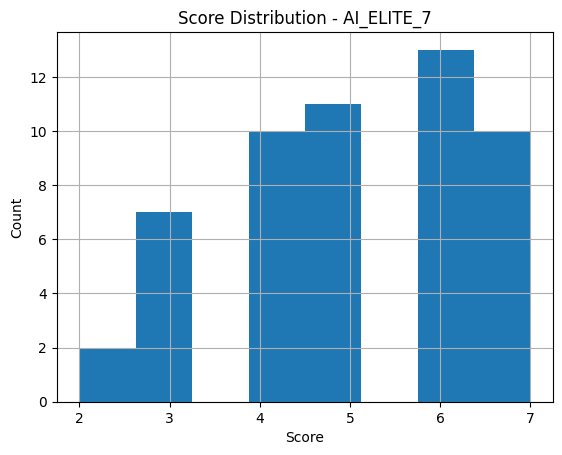

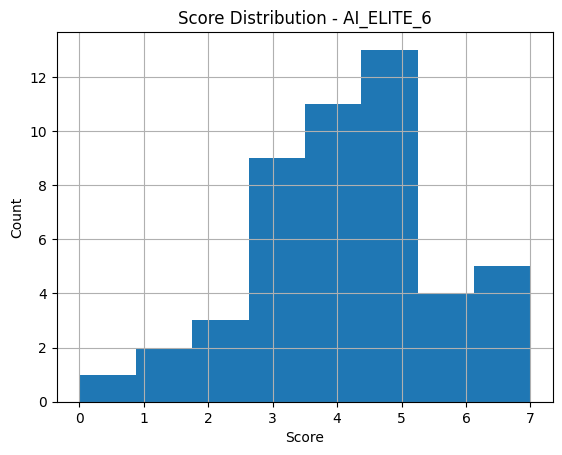

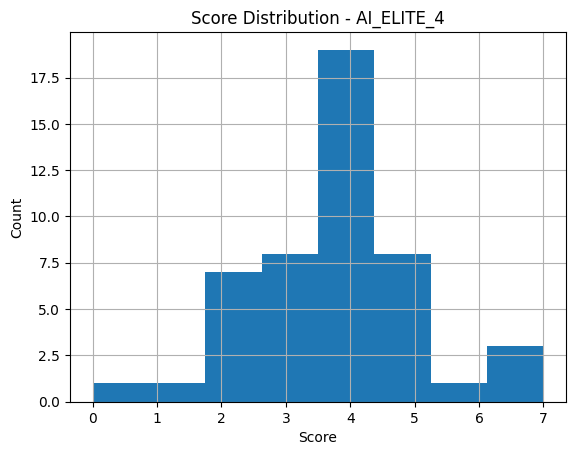

In [ ]:
for batch in df["Batch"].unique():
    plt.figure()
    df[df["Batch"] == batch]["Score_Num"].hist(bins=8)
    plt.title(f"Score Distribution - {batch}")
    plt.xlabel("Score")
    plt.ylabel("Count")
    plt.show()


<Figure size 640x480 with 0 Axes>

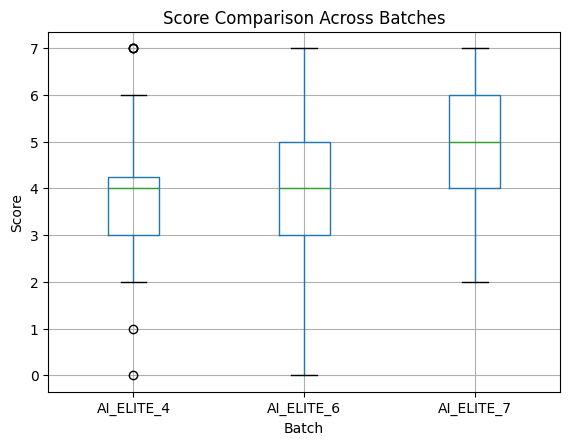

In [ ]:
plt.figure()
df.boxplot(column="Score_Num", by="Batch")
plt.title("Score Comparison Across Batches")
plt.suptitle("")
plt.ylabel("Score")
plt.show()


In [ ]:
def score_category(score):
    if score >= 6:
        return "High Performer"
    elif score >= 4:
        return "Average Performer"
    else:
        return "Low Performer"

df["Performance_Level"] = df["Score_Num"].apply(score_category)
print(df.shape)
df.head()

(149, 5)


,Batch,User_ID,Score,Score_Num,Performance_Level
0,AI_ELITE_7,uid_149,6 / 7,6,High Performer
1,AI_ELITE_7,uid_148,6 / 7,6,High Performer
2,AI_ELITE_7,uid_147,7 / 7,7,High Performer
3,AI_ELITE_7,uid_146,7 / 7,7,High Performer
4,AI_ELITE_7,uid_145,4 / 7,4,Average Performer


In [29]:
print("\n--- Performance Distribution (Percentage) ---")
performance_dist = (
    pd.crosstab(df["Batch"], df["Performance_Level"], normalize="index") * 100
)
performance_dist.round(2)


--- Performance Distribution (Percentage) ---


Performance_Level,Average Performer,High Performer,Low Performer
Batch,,,
AI_ELITE_4,56.25,8.33,35.42
AI_ELITE_6,50.00,18.75,31.25
AI_ELITE_7,39.62,43.40,16.98
